# 07_Classification_Baseline
Supervised RF/SVM baseline to test whether the 34 rhythm features are genre-discriminative,
following on from `06_Statistical_Analysis`. Uses **song-grouped cross-validation** — segments
from the same song never split across train/test, since the dataset is 109k segments from only
160 songs and plain k-fold would leak, inflating accuracy.

In [1]:
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

sys.path.append("..")
from utils.similarity import get_feature_columns

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
DATA_PATH = Path("../data/extracted/rhythm_features.pkl")
TABLES_DIR = Path("../tables")
FIGURES_DIR = Path("../figures")
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
with open(DATA_PATH, "rb") as f:
    rhythm_df = pickle.load(f)

rhythm_df.shape

(109089, 41)

In [4]:
METADATA_COLS = ["genre", "state", "artist", "gender", "song", "source", "source_file"]
metadata_cols = [c for c in METADATA_COLS if c in rhythm_df.columns]
feature_cols = get_feature_columns(rhythm_df, exclude=metadata_cols)

GENRES = ["Bauls", "Bhatiali", "Gidha", "Kajri", "Maand", "Sohar", "Sufi", "Uttarakhandi"]
present_genres = [g for g in GENRES if g in rhythm_df["genre"].unique()]

len(feature_cols), present_genres

(34,
 ['Bauls',
  'Bhatiali',
  'Gidha',
  'Kajri',
  'Maand',
  'Sohar',
  'Sufi',
  'Uttarakhandi'])

In [5]:
# Same cleaning as 06_Statistical_Analysis, for a directly comparable sample
analysis_df = rhythm_df[rhythm_df["genre"].isin(present_genres)].reset_index(drop=True)
analysis_df = analysis_df.dropna(subset=feature_cols)
analysis_df = analysis_df[np.isfinite(analysis_df[feature_cols].to_numpy()).all(axis=1)]

len(rhythm_df), len(analysis_df)

(109089, 109089)

In [6]:
# Drop zero-variance features — 06_Statistical_Analysis found 1 of 34 constant and skipped it
variances = analysis_df[feature_cols].var()
constant_cols = variances[variances == 0].index.tolist()
if constant_cols:
    print("Dropping constant feature(s):", constant_cols)
    feature_cols = [c for c in feature_cols if c not in constant_cols]

print(f"Using {len(feature_cols)} features")

X = analysis_df[feature_cols].to_numpy()
y = analysis_df["genre"].to_numpy()

# genre::song composite ID — a song name could in principle repeat across genres,
# so this is safer than grouping on "song" alone
groups = (analysis_df["genre"].astype(str) + "::" + analysis_df["song"].astype(str)).to_numpy()

le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f"{len(set(groups))} unique songs across {len(le.classes_)} genres")

Dropping constant feature(s): ['tempogram_stability']
Using 33 features
160 unique songs across 8 genres


## Held-out test split (song-grouped)
20% of songs held out entirely; test segments come from songs the model never saw during training.

In [7]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y_enc, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y_enc[train_idx], y_enc[test_idx]
groups_train = groups[train_idx]

print(f"Train segments: {len(train_idx)}  |  Test segments: {len(test_idx)}")
print(f"Train songs: {len(set(groups_train))}  |  Test songs: {len(set(groups[test_idx]))}")
assert set(groups_train).isdisjoint(set(groups[test_idx])), "Song leakage between train/test!"

Train segments: 90833  |  Test segments: 18256
Train songs: 128  |  Test songs: 32


## Chance-level baselines
Report these next to the paper's KNN (43.1%) and cosine-similarity numbers — with 8 genres,
"well above chance" needs a stated chance level to mean anything.

In [8]:
dummy_records = []
for strategy in ["stratified", "most_frequent", "uniform"]:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    dummy.fit(X_train, y_train)
    acc = accuracy_score(y_test, dummy.predict(X_test))
    dummy_records.append({"strategy": strategy, "test_accuracy": acc})
    print(f"Dummy ({strategy:12s}) test accuracy: {acc:.3f}")

n_classes = len(le.classes_)
print(f"\nRandom-guess baseline with {n_classes} balanced classes: {1/n_classes:.3f}")
dummy_df = pd.DataFrame(dummy_records)

Dummy (stratified  ) test accuracy: 0.131
Dummy (most_frequent) test accuracy: 0.168
Dummy (uniform     ) test accuracy: 0.126

Random-guess baseline with 8 balanced classes: 0.125


## Models — RF and SVM (RBF), song-grouped 5-fold CV on the training set

In [9]:
models = {
    "RandomForest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample",
                                        random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "SVM_RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=10, gamma="scale",
                     class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
}

gkf = GroupKFold(n_splits=5)
cv_results = {}
cv_summary_records = []

for name, pipe in models.items():
    scores = cross_validate(
        pipe, X_train, y_train, groups=groups_train, cv=gkf,
        scoring=["accuracy", "f1_macro"], n_jobs=-1
    )
    cv_results[name] = scores
    cv_summary_records.append({
        "model": name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_accuracy_std": scores["test_accuracy"].std(),
        "cv_f1_macro_mean": scores["test_f1_macro"].mean(),
        "cv_f1_macro_std": scores["test_f1_macro"].std(),
    })
    print(f"{name}")
    print(f"  CV accuracy : {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")
    print(f"  CV macro-F1 : {scores['test_f1_macro'].mean():.3f} ± {scores['test_f1_macro'].std():.3f}")

cv_summary_df = pd.DataFrame(cv_summary_records)

RandomForest
  CV accuracy : 0.289 ± 0.051
  CV macro-F1 : 0.279 ± 0.041
SVM_RBF
  CV accuracy : 0.327 ± 0.049
  CV macro-F1 : 0.304 ± 0.039


## Fit best model on full training set, evaluate on held-out test songs

In [10]:
best_name = max(cv_results, key=lambda n: cv_results[n]["test_f1_macro"].mean())
print(f"Best by CV macro-F1: {best_name}")

best_model = models[best_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average="macro")
print(f"\nHeld-out test accuracy: {test_acc:.3f}")
print(f"Held-out test macro-F1: {test_f1:.3f}\n")

report_dict = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report_dict).T
report_df.to_csv(TABLES_DIR / "classification_report_baseline.csv")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Best by CV macro-F1: SVM_RBF

Held-out test accuracy: 0.404
Held-out test macro-F1: 0.366

              precision    recall  f1-score   support

       Bauls       0.30      0.33      0.31      2324
    Bhatiali       0.20      0.25      0.22      1300
       Gidha       0.25      0.45      0.32       755
       Kajri       0.33      0.24      0.28      3063
       Maand       0.25      0.25      0.25      1972
       Sohar       0.61      0.65      0.63      3609
        Sufi       0.54      0.54      0.54      3165
Uttarakhandi       0.44      0.32      0.37      2068

    accuracy                           0.40     18256
   macro avg       0.37      0.38      0.37     18256
weighted avg       0.41      0.40      0.40     18256



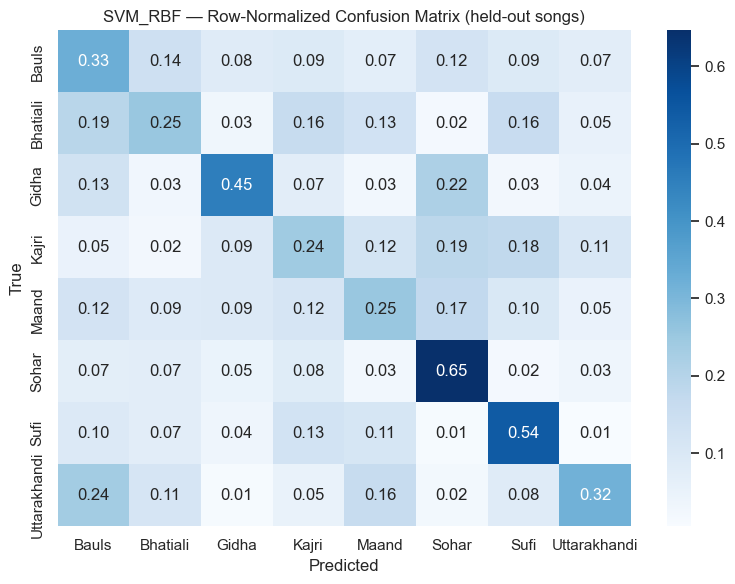

In [11]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"{best_name} — Row-Normalized Confusion Matrix (held-out songs)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "classification_confusion_matrix.png", dpi=300)
plt.show()

## Feature importance vs. the eta-squared ranking from 06_Statistical_Analysis
Loads `ranked_significant_features.csv` (already written by 06) and checks whether the
features the classifier actually relies on line up with the ones flagged as statistically
significant — this is the check that was missing from the paper.

In [12]:
if best_name == "RandomForest":
    importances = best_model.named_steps["clf"].feature_importances_
else:
    rf_ref = RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample",
                                     random_state=RANDOM_STATE, n_jobs=-1)
    rf_ref.fit(StandardScaler().fit_transform(X_train), y_train)
    importances = rf_ref.feature_importances_

rf_importance_df = pd.DataFrame({"feature": feature_cols, "rf_importance": importances})
rf_importance_df = rf_importance_df.sort_values("rf_importance", ascending=False).reset_index(drop=True)
rf_importance_df["rf_rank"] = rf_importance_df.index + 1

ranked_path = TABLES_DIR / "ranked_significant_features.csv"
if ranked_path.exists():
    eta_df = pd.read_csv(ranked_path)[["feature", "eta_squared_H", "combined_rank"]]
    eta_df = eta_df.rename(columns={"combined_rank": "eta_rank"})
    compare_df = rf_importance_df.merge(eta_df, on="feature", how="left")
    compare_df.to_csv(TABLES_DIR / "rf_importance_vs_eta_squared.csv", index=False)

    top10_rf = set(rf_importance_df.head(10)["feature"])
    top10_eta = set(eta_df.sort_values("eta_rank").head(10)["feature"])
    overlap = top10_rf & top10_eta
    print(f"Top-10 overlap between RF importance and eta-squared ranking: {len(overlap)}/10")
    print(sorted(overlap))
else:
    print(f"{ranked_path} not found — run 06_Statistical_Analysis first to generate it.")
    compare_df = rf_importance_df

rf_importance_df.head(10)

Top-10 overlap between RF importance and eta-squared ranking: 6/10
['energy_max', 'energy_mean', 'energy_min', 'frame_entropy_mean', 'frame_entropy_std', 'tempogram_var']


,feature,rf_importance,rf_rank
0,frame_entropy_mean,0.091929,1
1,modulation_dominant_freq_bin,0.057593,2
2,frame_entropy_std,0.056391,3
3,energy_mean,0.051874,4
4,flux_sum,0.044917,5
5,flux_mean,0.044216,6
6,energy_max,0.043990,7
7,energy_skew,0.043241,8
8,energy_min,0.039834,9
9,tempogram_var,0.037811,10


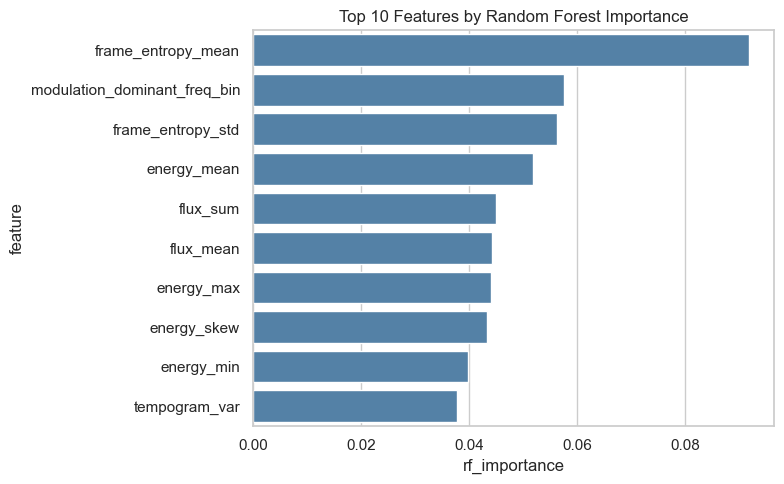

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=rf_importance_df.head(10), x="rf_importance", y="feature", ax=ax, color="steelblue")
ax.set_title("Top 10 Features by Random Forest Importance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rf_feature_importance_top10.png", dpi=300)
plt.show()

## Save summary table for the paper

In [14]:
baseline_summary_df = pd.concat([
    dummy_df.assign(model=lambda d: "Dummy_" + d["strategy"]).drop(columns="strategy")
             .rename(columns={"test_accuracy": "test_accuracy"}),
    cv_summary_df,
], ignore_index=True, sort=False)

baseline_summary_df.loc[baseline_summary_df["model"] == best_name, "test_accuracy"] = test_acc
baseline_summary_df.loc[baseline_summary_df["model"] == best_name, "test_f1_macro"] = test_f1

baseline_summary_df.to_csv(TABLES_DIR / "classification_baseline_summary.csv", index=False)
baseline_summary_df

,test_accuracy,model,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std,test_f1_macro
0,0.131135,Dummy_stratified,NaN,NaN,NaN,NaN,NaN
1,0.167780,Dummy_most_frequent,NaN,NaN,NaN,NaN,NaN
2,0.126315,Dummy_uniform,NaN,NaN,NaN,NaN,NaN
3,NaN,RandomForest,0.288796,0.050926,0.279115,0.041069,NaN
4,0.403539,SVM_RBF,0.326895,0.049022,0.303528,0.039464,0.366057


## For the paper
Add a Section V.D ("Supervised Classification Baseline") reporting:
- Chance baseline (majority-class ≈ largest genre share, uniform-random ≈ 1/8 = 12.5%)
- Song-grouped 5-fold CV accuracy/macro-F1 for RF and SVM (mean ± std) — `classification_baseline_summary.csv`
- Held-out test accuracy/macro-F1 on unseen songs, per-genre precision/recall — `classification_report_baseline.csv`
- Confusion matrix (`classification_confusion_matrix.png`) — which genre pairs get confused
  tells you which rhythmic distinctions are real vs. which the significance tests picked up
  but aren't actually separable
- RF importance vs. eta-squared top-10 overlap (`rf_importance_vs_eta_squared.csv`) — if
  `energy_min` and `frame_entropy_mean` show up in both rankings, that's your strongest
  discriminative-features claim; if they diverge, that's worth a sentence in Discussion
  rather than leaving unaddressed.